In [1]:
def serial_ports():
    """ Lists serial port names

        :raises EnvironmentError:
            On unsupported or unknown platforms
        :returns:
            A list of the serial ports available on the system
    """
    if sys.platform.startswith('win'):
        ports = ['COM%s' % (i + 1) for i in range(256)]
    elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
        # this excludes your current terminal "/dev/tty"
        ports = glob.glob('/dev/tty[A-Za-z]*')
    elif sys.platform.startswith('darwin'):
        ports = glob.glob('/dev/tty.*')
    else:
        raise EnvironmentError('Unsupported platform')

    result = []
    for port in ports:
        try:
            s = serial.Serial(port)
            s.close()
            result.append(port)
        except (OSError, serial.SerialException):
            pass
    return result

In [10]:
#to test single or 2 bulbs

#before running with PMM, try this to see if rs485 working right
#make sure to run previous cell first to define serial_ports

import minimalmodbus
import serial
import sys
import glob
 
print(serial_ports())
bulb101 = minimalmodbus.Instrument(port = '/dev/tty.usbserial-B003LY1G',\
                                       slaveaddress = 101,\
                                       mode = minimalmodbus.MODE_RTU)
bulb102 = minimalmodbus.Instrument(port = '/dev/tty.usbserial-B003LY1G',\
                                      slaveaddress = 103,\
                                      mode = minimalmodbus.MODE_RTU)
bulb101.serial.baudrate = 9600
bulb101.write_register(0x1001, 10, functioncode = 6) #1001 to change power current
#bulb101.write_register(0x1008, 101, functioncode = 6) #1008 to change address name

bulb102.serial.baudrate = 9600
# bulb102.write_register(0x1001, 23, functioncode = 6)
bulb102.write_register(0x1008, 62, functioncode = 6) #1008 to change address name

 

['/dev/tty.debug-console', '/dev/tty.wlan-debug', '/dev/tty.SoloPro', '/dev/tty.TOZO-T10', '/dev/tty.TOZOT10', '/dev/tty.Bluetooth-Incoming-Port', '/dev/tty.usbserial-B003LY1G']


In [2]:
#run this to see if PMM working

from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

# Run these 2 lines:
# PMM.Set_Bulb_VI('all', 15, 2) #set bulbs(all, volts, amps)
# PMM.Activate_Bulb('all')

# OR run these 2 lines:
PMM.Config_Check()
PMM.Deactivate_Bulb('all')

checking port /dev/tty.usbserial-B003LKT9
checking port /dev/tty.usbserial-B0032GMG
checking port /dev/tty.usbserial-B003L2CD
checking port /dev/tty.usbserial-B003LJKJ
checking port /dev/tty.usbserial-B0032GQ2
checking port /dev/tty.usbserial-B0019Q3M
checking port /dev/tty.usbserial-B0032389
checking port /dev/tty.usbserial-B001K6BU
checking port /dev/tty.usbserial-B0013LEA
checking port /dev/tty.usbserial-B00295EU
Starting threads for 10 ports...
Waiting for all threads to complete...
Finished '_parallel_check_bulb' on all ports.
Starting threads for 10 ports...
Waiting for all threads to complete...
[WARN] Addr 23: Activate_Bulb failed (1/3); retrying…
[WARN] Addr 61: Activate_Bulb failed (1/3); retrying…
[WARN] Addr 32: Activate_Bulb failed (1/3); retrying…
[WARN] Addr 12: Activate_Bulb failed (1/3); retrying…
[WARN] Addr 2: Activate_Bulb failed (1/3); retrying…
[WARN] Addr 72: Activate_Bulb failed (1/3); retrying…
[WARN] Addr 83: Activate_Bulb failed (1/3); retrying…
[WARN] Addr 5

In [ ]:
# #solved problem: on deactivate all, gets stuck
# #now add in parallelizing P.S. by bus to make it faster

# from PMM.PMMInSitu import PMMInSitu
# PMM = PMMInSitu('../confs/conf_test.yaml')

# import time
# from concurrent.futures import ThreadPoolExecutor, as_completed


# def _cmd_with_retry(cmd, addr, cmd_args, cmd_kwargs, tries=3, delay=4.5):
#     """Calls a bulb command and automatically retries on any exception"""
#     for attempt in range(tries):
#         try:
#             cmd(addr, *cmd_args, **cmd_kwargs)
#             return True
#         except Exception as err:
#             if attempt == tries - 1:
#                 print(f"[FAIL] Addr {addr}: {cmd.__name__} → {err}")
#             else:
#                 print(f"[WARN] Addr {addr}: {cmd.__name__} failed "
#                       f"({attempt+1}/{tries}); retrying…")
#                 time.sleep(delay)
#     return False


# def parallel_bulb_op(
#         pmm,
#         cmd_name,
#         *cmd_args,        # extra positional args for the command
#         tries=3,
#         delay=0.6,
#         max_workers=None,
#         **cmd_kwargs      # extra keyword args for the command
# ):
#     """
#     Run `pmm.<cmd_name>(addr, *cmd_args, **cmd_kwargs)` in parallel
#     across RS-485 buses, column-by-column.

#     Examples
#     --------
#     • Set every bulb to 5 V, 1 A:
#         parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1)

#     • Activate all bulbs:
#         parallel_bulb_op(PMM, "Activate_Bulb")
#     """
#     cmd = getattr(pmm, cmd_name)

#     # Keep each USB port open to avoid OS churn
#     for inst in pmm.bulbs['all'].values():
#         inst.serial.close_port_after_each_call = False

#     port_to_addrs = pmm.config["serial_ports"]
#     addr_lists = list(port_to_addrs.values())
#     n_cols = max(len(lst) for lst in addr_lists)

#     workers = max_workers or len(addr_lists)
#     with ThreadPoolExecutor(max_workers=workers) as pool:
#         for col in range(n_cols):
#             futures = [
#                 pool.submit(
#                     _cmd_with_retry,
#                     cmd,
#                     lst[col],
#                     cmd_args,
#                     cmd_kwargs,
#                     tries,
#                     delay,
#                 )
#                 for lst in addr_lists
#                 if col < len(lst)
#             ]
#             for fut in as_completed(futures):
#                 fut.result()

#     # Final broadcast for on/off ops
#     if cmd_name in ("Activate_Bulb", "Deactivate_Bulb"):
#         try:
#             cmd("all", *cmd_args, **cmd_kwargs)
#         except Exception:
#             pass
        

# # 1) Set every bulb to 5 V and 1 A in parallel
# parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1, tries=3, delay=0.5)

# # 2) Now turn them all on, also in parallel
# parallel_bulb_op(PMM, "Activate_Bulb", tries=3, delay=0.5)

# # 3) Turn everything off
# parallel_bulb_op(PMM, "Deactivate_Bulb", tries=3, delay=0.5)



In [ ]:
# ##attempt 2
# #solved problem: on deactivate all, gets stuck
# #now add in parallelizing P.S. by bus to make it faster

# from PMM.PMMInSitu import PMMInSitu
# PMM = PMMInSitu('../confs/conf_test.yaml')

# import time
# from concurrent.futures import ThreadPoolExecutor, as_completed


# def _cmd_with_retry(cmd, addr, cmd_args, cmd_kwargs, tries=3, delay=4.5):
#     """Calls a bulb command and automatically retries on any exception"""
#     for attempt in range(tries):
#         try:
#             cmd(addr, *cmd_args, **cmd_kwargs)
#             return True
#         except Exception as err:
#             if attempt == tries - 1:
#                 print(f"[FAIL] Addr {addr}: {cmd.__name__} → {err}")
#             else:
#                 print(f"[WARN] Addr {addr}: {cmd.__name__} failed "
#                       f"({attempt+1}/{tries}); retrying…")
#                 time.sleep(delay)
#     return False


# import threading # Import the module

# def parallel_bulb_op(self, cmd_name, *cmd_args, tries=3, delay=0.6, **cmd_kwargs):
#     """
#     Runs a command on all bulbs, processing each serial port's list of bulbs in parallel
#     using the fundamental 'threading' module.
#     """
#     cmd = getattr(self, cmd_name)
#     port_to_addrs = self.config["serial_ports"]

#     def process_one_port(address_list):
#         for addr in address_list:
#             self._cmd_with_retry(cmd, addr, cmd_args, cmd_kwargs, tries, delay)

#     threads = [] # A list to keep track of the threads we create.

#     # --- Step 1: Create and Start All Threads ---
#     print(f"Starting threads for {len(port_to_addrs)} ports...")
#     for addr_list in port_to_addrs.values():
#         # Create a thread object, telling it which function to run (target).
#         thread = threading.Thread(target=process_one_port, args=(addr_list,))
#         threads.append(thread)
#         # Start the thread. It will begin running in the background.
#         thread.start()

#     # --- Step 2: Wait for All Threads to Finish ---
#     print("Waiting for all threads to complete...")
#     for thread in threads:
#         # The .join() method tells the main script to pause and wait
#         # until this specific thread has finished its work.
#         thread.join()

#     print(f"Finished '{cmd_name}' on all ports.")
        

# # 1) Set every bulb to 5 V and 1 A in parallel
# parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1, tries=3, delay=0.5)

# # 2) Now turn them all on, also in parallel
# parallel_bulb_op(PMM, "Activate_Bulb", tries=3, delay=0.5)

# # 3) Turn everything off
# parallel_bulb_op(PMM, "Deactivate_Bulb", tries=3, delay=0.5)



In [ ]:
#Parallelize

from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

import time
import threading

def _cmd_with_retry(self, cmd, addr, cmd_args, cmd_kwargs, tries=3, delay=0.6):
        """Call a bulb command and retry on any exception."""
        for attempt in range(tries):
            try:
                cmd(addr, *cmd_args, **cmd_kwargs)
                return True
            except Exception as err:
                if attempt == tries - 1:
                    print(f"[FAIL] Addr {addr}: {cmd.__name__} → {err}")
                else:
                    print(f"[WARN] Addr {addr}: {cmd.__name__} failed ({attempt+1}/{tries}); retrying…")
                    time.sleep(delay)
        return False
    
def parallel_bulb_op(self, cmd_name, *cmd_args, tries=3, delay=0.6, **cmd_kwargs):
        """
        Runs a command on all bulbs, processing each serial port's list of bulbs in parallel
        using the 'threading' module.
        """
        cmd = getattr(self, cmd_name)
        port_to_addrs = self.config["serial_ports"]

        def process_one_port(address_list):
            for addr in address_list:
                self._cmd_with_retry(cmd, addr, cmd_args, cmd_kwargs, tries, delay)
        threads = []
        print(f"Starting threads for {len(port_to_addrs)} ports...")
        for addr_list in port_to_addrs.values():
            thread = threading.Thread(target=process_one_port, args=(addr_list,))
            threads.append(thread)
            thread.start()
        print("Waiting for all threads to complete...")
        for thread in threads:
            thread.join() #wait until threads finished
        print(f"Finished '{cmd_name}' on all ports.")            
    
    def Address(self, coords):
        """
        Takes array coordinates and returns a bulb address

        Args:
            coords: tuple/list; e.g. (i,j)
        """
        return (coords[0]+self.config['array-x']*coords[1])
    
    
#1) Set every bulb to 5 V and 1 A in parallel
parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1, tries=3, delay=0.5)

# 2) Now turn them all on, also in parallel
parallel_bulb_op(PMM, "Activate_Bulb", tries=3, delay=0.5)

# 3) Turn everything off
parallel_bulb_op(PMM, "Deactivate_Bulb", tries=3, delay=0.5)

In [ ]:
# now for mapping the bulbs

# ──────────────────────────────────────────────────────────────────────────
#  91‑bulb hexagon · reliable sequential status read (● on / ○ off)
# ──────────────────────────────────────────────────────────────────────────
import math, time, matplotlib.pyplot as plt, contextlib, io
from itertools import chain

def _find_inst(pmm, addr):
    ent = pmm.bulbs.get(addr) or pmm.bulbs.get(str(addr))
    return ent if hasattr(ent, 'write_register') else ent.get('Inst')

def _all_addrs_in_yaml(pmm):
    # keep port order from YAML for deterministic bus traversal
    return list(chain.from_iterable(pmm.config['serial_ports'].values()))

def plot_hex_bulbs(pmm, pause=0.03):
    R = 5
    addrs = _all_addrs_in_yaml(pmm)[:91]          # 1‥91 in YAML order

    # axial coordinates row‑major
    coords = [(q, r)
              for r in range(-R, R + 1)
              for q in range(max(-R, -r - R), min(R, -r + R) + 1)]

    # status probe — sequential to avoid bus collisions
    on_set = set()
    for addr in addrs:
        inst = _find_inst(pmm, addr)
        if inst is None:
            continue
        with contextlib.redirect_stdout(io.StringIO()):
            try:
                if inst.read_register(0x1004) & 0x0001:
                    on_set.add(addr)
            except Exception:
                pass
        time.sleep(pause)                        # short breather

    # build plot arrays
    xs, ys, labels, fills = [], [], [], []
    for addr, (q, r) in zip(addrs, coords):
        xs.append((q + r/2) * math.sqrt(3))
        ys.append((3/2) * r)
        labels.append(addr)
        fills.append(addr in on_set)

    # cosmetic shift
    dx, dy = min(xs), min(ys)
    xs = [x - dx for x in xs];  ys = [y - dy for y in ys]

    # draw
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter([x for x, f in zip(xs, fills) if not f],
               [y for y, f in zip(ys, fills) if not f],
               s=400, facecolors='none', edgecolors='black', linewidths=1.2)
    ax.scatter([x for x, f in zip(xs, fills) if f],
               [y for y, f in zip(ys, fills) if f],
               s=400, facecolors='black', edgecolors='black')

    for x, y, lab in zip(xs, ys, labels):
        ax.text(x, y, str(lab), ha='center', va='center',
                fontsize=7, color='red')

    ax.set_aspect('equal');  ax.axis('off')
    ax.set_title("91‑bulb hexagon  (● on / ○ off)")
    plt.tight_layout();  plt.show()

# ─── run after any activation/deactivation ────────────────────────────────
plot_hex_bulbs(PMM)


checking port /dev/tty.usbserial-B003LKT9
checking supply:  1
checking supply:  2
checking supply:  3
checking supply:  4
checking supply:  5
checking supply:  6
checking supply:  7
checking supply:  8
checking supply:  9
checking supply:  10
checking port /dev/tty.usbserial-B0032GMG
checking supply:  11
checking supply:  12
checking supply:  13
checking supply:  14
checking supply:  15
checking supply:  16
checking supply:  17
checking supply:  18
checking supply:  19
checking supply:  20
checking port /dev/tty.usbserial-B003L2CD
checking supply:  21
checking supply:  22
checking supply:  23
checking supply:  24
checking supply:  25
checking supply:  26
checking supply:  27
checking supply:  28
checking supply:  29
checking supply:  30
checking port /dev/tty.usbserial-B003LJKJ
checking supply:  31
checking supply:  32
checking supply:  33
checking supply:  34
checking supply:  35
checking supply:  36
checking supply:  37
checking supply:  38
checking supply:  39
checking supply:  40
c

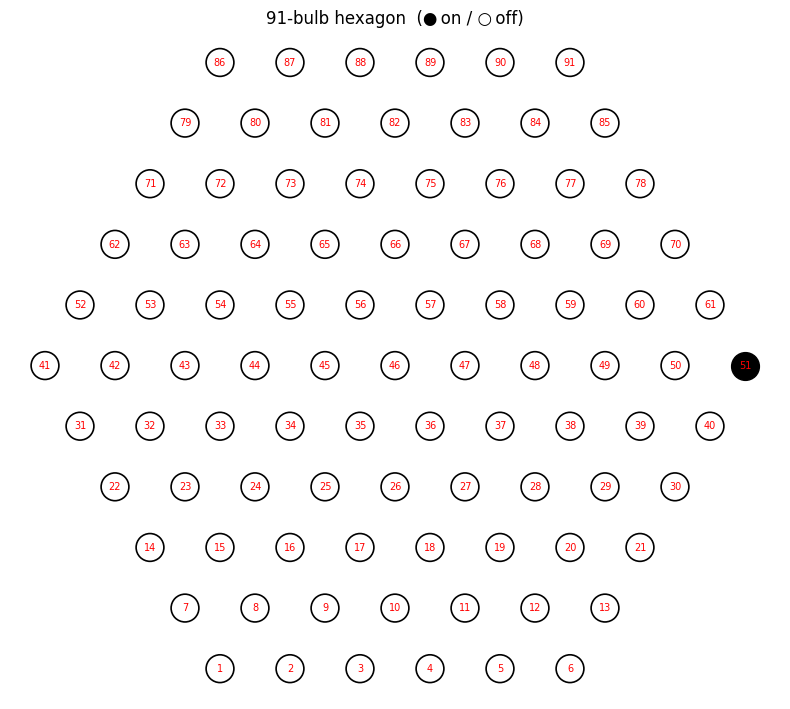

In [ ]:
###############YAY USE THIS#######################################
#(now making sure i can set individual bulbs not just all)
####run PREVIOUS cell to get plot

from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections.abc import Iterable


def _cmd_with_retry(cmd, addr, cmd_args, cmd_kwargs, tries=3, delay=0.3):
    """Calls a bulb command and automatically retries on any exception"""
    for attempt in range(tries):
        try:
            cmd(addr, *cmd_args, **cmd_kwargs)
            return True
        except Exception as err:
            if attempt == tries - 1:
                print(f"[FAIL] Addr {addr}: {cmd.__name__} → {err}")
            else:
                print(f"[WARN] Addr {addr}: {cmd.__name__} failed "
                      f"({attempt+1}/{tries}); retrying…")
                time.sleep(delay)
    return False


def parallel_bulb_op(
        pmm,
        cmd_name,
        *cmd_args,        # extra positional args for the command
        bulbs='all',      # NEW ─ int | Iterable[int] | 'all'
        tries=3,
        delay=0.3,
        max_workers=None,
        **cmd_kwargs      # extra keyword args for the command
):
    """
    Run `pmm.<cmd_name>(addr, *cmd_args, **cmd_kwargs)` in parallel
    across RS-485 buses, column-by-column.

    Parameters
    ----------
    pmm   : PMMInSitu instance
    cmd_name : str   – method name in PMMInSitu (e.g. "Set_Bulb_VI")
    bulbs : int | Iterable[int] | "all"
        • int            → that single address
        • iterable[int]  → explicit list/tuple/set of addresses
        • "all" (str)    → every address in the config
    ...

    Examples
    --------
    • Turn on bulb 3 with 30 V, 5 A:
        parallel_bulb_op(PMM, "Set_Bulb_VI", 30, 5, bulbs=3)
        parallel_bulb_op(PMM, "Activate_Bulb", bulbs=3)

    • Turn on bulbs 3, 7, 11:
        parallel_bulb_op(PMM, "Activate_Bulb", bulbs=[3, 7, 11])

    • Full-array ops (unchanged):
        parallel_bulb_op(PMM, "Deactivate_Bulb", bulbs='all')
    """
    cmd = getattr(pmm, cmd_name)

    # Normalise the target set -----------------------------------------------
    all_addrs = {a for lst in pmm.config["serial_ports"].values() for a in lst}
    if bulbs == 'all':
        target_set = all_addrs
    elif isinstance(bulbs, int):
        target_set = {bulbs}
    elif isinstance(bulbs, Iterable):
        target_set = set(bulbs)
    else:
        raise ValueError("bulbs must be int, iterable of ints, or 'all'")

    # Keep each USB port open to avoid OS churn
    for inst in pmm.bulbs['all'].values():
        inst.serial.close_port_after_each_call = False

    # Build per-bus, column-aligned lists but only with targets ---------------
    port_to_addrs = {
        port: [a for a in addr_list if a in target_set]
        for port, addr_list in pmm.config["serial_ports"].items()
    }
    addr_lists = [lst for lst in port_to_addrs.values() if lst]   # drop empties
    if not addr_lists:
        print("No matching bulb addresses!")
        return

    n_cols = max(len(lst) for lst in addr_lists)
    workers = max_workers or len(addr_lists)

    # Parallel loop -----------------------------------------------------------
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for col in range(n_cols):
            futures = [
                pool.submit(
                    _cmd_with_retry,
                    cmd,
                    lst[col],
                    cmd_args,
                    cmd_kwargs,
                    tries,
                    delay,
                )
                for lst in addr_lists
                if col < len(lst)
            ]
            for fut in as_completed(futures):
                fut.result()

    # Final broadcast remains, but only for full-array ops --------------------
    if bulbs == 'all' and cmd_name in ("Activate_Bulb", "Deactivate_Bulb"):
        try:
            cmd("all", *cmd_args, **cmd_kwargs)
        except Exception:
            pass


# ─────────────────────────────────────────────────────────
# EXAMPLES
# ---------------------------------------------------------------------------

# 1) Single bulb
#parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1, bulbs=51) 
#parallel_bulb_op(PMM, "Activate_Bulb", bulbs=51)
#parallel_bulb_op(PMM, "Deactivate_Bulb", bulbs=51)

# 2) A few bulbs
# parallel_bulb_op(PMM, "Set_Bulb_VI", 30, 5, bulbs=3, 7, 11)
# parallel_bulb_op(PMM, "Activate_Bulb", bulbs=[3, 7, 11])
# parallel_bulb_op(PMM, "Deactivate_Bulb", bulbs=[3, 7, 11])

# 3) Entire array (unchanged use)
parallel_bulb_op(PMM, "Set_Bulb_VI", 5, 1,  bulbs='all')
parallel_bulb_op(PMM, "Activate_Bulb",        bulbs='all')
parallel_bulb_op(PMM, "Deactivate_Bulb",      bulbs='all')

plot_hex_bulbs(PMM)


In [1]:
#check port for VNA
# install visa https://www.rohde-schwarz.com/us/applications/r-s-visa-application-note_56280-148812.html

from RsInstrument import *

# List *everything* the VISA layer can open right now
print(RsInstrument.list_resources('?*INSTR'))
# USB only
print(RsInstrument.list_resources('?*USB*')) #not working??? 

/opt/anaconda3/envs/pmm_x86/lib/python3.10/site-packages/pyvisa_py/tcpip.py:122: UserWarning: TCPIP::hislip resource discovery requires the zeroconf package to be installed... try 'pip install zeroconf'
  warnings.warn(


('ASRL/dev/cu.debug-console::INSTR', 'ASRL/dev/cu.wlan-debug::INSTR', 'ASRL/dev/cu.usbserial-B003L2CD::INSTR', 'ASRL/dev/cu.usbserial-B0032GQ2::INSTR', 'ASRL/dev/cu.usbserial-B0032GMG::INSTR', 'ASRL/dev/cu.usbserial-B0013LEA::INSTR', 'ASRL/dev/cu.usbserial-B0019Q3M::INSTR', 'ASRL/dev/cu.usbserial-B003LKT9::INSTR', 'ASRL/dev/cu.usbserial-B001K6BU::INSTR', 'ASRL/dev/cu.usbserial-B003LJKJ::INSTR', 'ASRL/dev/cu.usbserial-B00295EU::INSTR', 'ASRL/dev/cu.usbserial-B0032389::INSTR', 'ASRL/dev/cu.usbserial-13::INSTR', 'ASRL/dev/cu.usbserial-21::INSTR', 'ASRL/dev/cu.usbserial-14::INSTR', 'ASRL/dev/cu.usbserial-19::INSTR', 'ASRL/dev/cu.usbserial-15::INSTR', 'ASRL/dev/cu.usbserial-12::INSTR', 'ASRL/dev/cu.usbserial-17::INSTR', 'ASRL/dev/cu.usbserial-20::INSTR', 'ASRL/dev/cu.usbserial-16::INSTR', 'ASRL/dev/cu.usbserial-18::INSTR', 'ASRL/dev/cu.SoloPro::INSTR', 'ASRL/dev/cu.TOZO-T10::INSTR', 'ASRL/dev/cu.Bluetooth-Incoming-Port::INSTR', 'USB0::2733::448::101603::0::INSTR')
('ASRL/dev/cu.usbserial-B0

In [ ]:
#vna
from PMM.PMMInSitu import PMMInSitu

resource = 'USB0::0x0AAD::0x01C0::101603::INSTR' 
vna = RsInstrument(resource, options="SelectVisa='rs'")


In [ ]:
Get_S21_S31(self)

In [ ]:
#mirror plot

from RsInstrument import RsInstrument
import numpy as np
import matplotlib.pyplot as plt

#addr = 'USB0::0x0AAD::0x0119::022019943::INSTR' 
addr = 'USB0::0x0AAD::0x01C0::101603::INSTR'
vna  = RsInstrument(addr)
#vna  = RsInstrument(addr, reset=True, id_query=True, options="SelectVisa='rs'")
#^double check all those defaults************ (after addresss)
#try new pmm environment
#try restart
#rosetta

# Basic preset
vna.write_str('SYST:PRES; *CLS')

# Channel 1 sweep and trace definition
vna.write_str('SENS1:FREQ:STAR 2e9')
vna.write_str('SENS1:FREQ:STOP 3e9')
vna.write_str('SENS1:SWE:POIN 801')
vna.write_str('CALC1:PAR:DEF "Meas",S21')
vna.write_str('CALC1:PAR:SEL "Meas"')
vna.write_str('CALC1:FORM MLOG')

# Trigger a single sweep and wait
vna.write_str('INIT:IMM; *WAI')

# Fetch frequency axis and trace data
f     = np.array(vna.query_float_list('SENS1:FREQ:DATA?'))
s21db = np.array(vna.query_float_list('CALC1:DATA:FDAT?'))

vna.close()   # always clean up

# Plot
plt.plot(f/1e9, s21db)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S21 (dB)')
plt.title('ZNB40 S21')
plt.grid(True)
plt.show()


In [ ]:
PMM.Deactivate_Bulb('all', parallel=False)
#PMM.Activate_Bulb('all')

In [ ]:
import numpy as np
from PMM.PMMInSitu import PMMInSitu
PMM = PMMInSitu('../confs/conf_test.yaml')

rho_settings = np.random.rand(91) * 5.0 
wp_max_setting = 15.0

PMM.ArraySet_Rho(rho_settings, wp_max_setting)

print("ArraySet_Rho command has been sent successfully.")


In [ ]:
#Define the initial parameters for the optimization (manual start)

import numpy as np
from PMM.PMMInSitu import PMMInSitu
import time

# 1. Initialize the PMMInSitu class instance
# Make sure the path to your configuration file is correct.
PMM = PMMInSitu('../confs/conf_test.yaml')

# 2. Define the manual rho array you want to test
initial_rho = np.zeros(91)
on_value = 18.0 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91] # <-- Change these addresses to test different bulbs

for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value

# 3. Set the max plasma frequency (must be a realistic value for your setup)
# This should match the value from your main optimization script.
max_plasma_freq_GHz = 12.0 


# --- EXECUTION AND CLEANUP ---

try:
    # 4. Activate the array using your manual rho configuration
    print("Activating the array with your manual configuration...")
    print(f"Bulbs to check: {bulbs_to_turn_on}")
    
    PMM.ArraySet_Rho(
        rho=initial_rho,
        wp_max=max_plasma_freq_GHz,
        knob=0.5,
        scale=1.0
    )

    # 5. Keep bulbs on for inspection
    on_duration = 20  # seconds
    print(f"Bulbs are ON. You have {on_duration} seconds to visually inspect them.")
    time.sleep(on_duration)

finally:
    # 6. CRITICAL: This will run no matter what, ensuring bulbs are turned off.
    print("\nDeactivating all bulbs...")
    PMM.Deactivate_Bulb('all')
    print("Test complete. All bulbs are now off.")

checking port /dev/tty.usbserial-B003LKT9
checking port /dev/tty.usbserial-B0032GMG
checking port /dev/tty.usbserial-B003L2CD
checking port /dev/tty.usbserial-B003LJKJ
checking port /dev/tty.usbserial-B0032GQ2
checking port /dev/tty.usbserial-B0019Q3M
checking port /dev/tty.usbserial-B0032389
checking port /dev/tty.usbserial-B001K6BU
checking port /dev/tty.usbserial-B0013LEA
checking port /dev/tty.usbserial-B00295EU
Starting threads for 10 ports...
Waiting for all threads to complete...
Finished '_parallel_check_bulb' on all ports.
Using manual initial_rho with bulbs ON: [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91]

Activating array...
Starting threads for 10 ports...
Waiting for all threads to complete...
[WARN] Addr 2: Activate_Bulb failed (1/3); retrying…[WARN] Addr 52: Activate_Bulb failed (1/3); retrying…

[WARN] Addr 42: Activate_Bulb failed (1/3); retrying

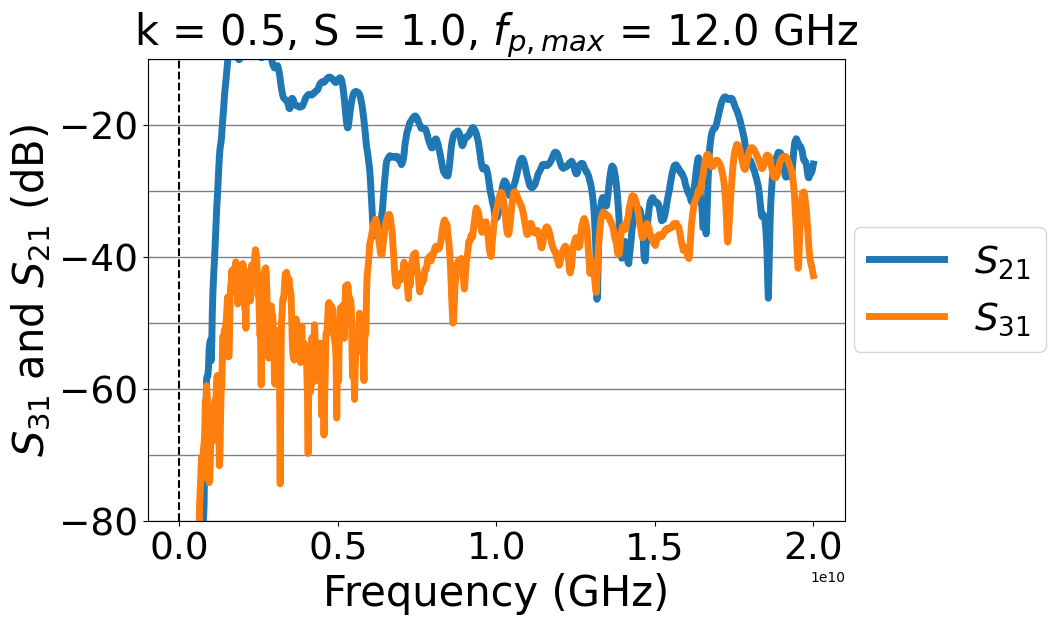

In [17]:
# See initial parameters for the optimization (manual start)

import numpy as np
from PMM.PMMInSitu import PMMInSitu
import time

# 1. Initialize the PMMInSitu class instance
PMM = PMMInSitu('../confs/conf_test.yaml')

# 2. Define the initial_rho array you want to test
initial_rho = np.zeros(91)
on_value = 19.0 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91]
for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value
print(f"Using manual initial_rho with bulbs ON: {bulbs_to_turn_on}")

# 3. Define the core settings needed for the functions
max_plasma_freq_GHz = 12.0
operating_freq_GHz = 6.0
knob = 0.5
scale = 1.0

try:
    # 4. Activate the array with your rho configuration
    print("\nActivating array...")
    PMM.ArraySet_Rho(
        rho=initial_rho,
        wp_max=max_plasma_freq_GHz,
        knob=knob,
        scale=scale
    )
    
    # Let the plasma stabilize for a moment
    time.sleep(1) 

    # 5. Get the S-parameter data from the VNA
    print("Getting VNA measurement...")
    freq, S21, S31 = PMM.Get_S21_S31()
    print("Measurement complete.")

finally:
    # 6. CRITICAL: Deactivate all bulbs
    print("Deactivating all bulbs...")
    PMM.Deactivate_Bulb('all')
    print("Bulbs are now off.")

# 7. Generate and display the graph of the measurement
print("\nGenerating plot...")
PMM.Trans_Plot_2Port(
    savepath='./initial_rho_test_plot.pdf', # File will be saved here
    freq=freq,
    S21=S21,
    S31=S31,
    fpm=max_plasma_freq_GHz,
    k=knob,
    S=scale,
    f=[operating_freq_GHz] # Draws a line at your target frequency
)

In [ ]:
# Run optimize_waveguide

import numpy as np
from PMM.PMMInSitu import PMMInSitu

# 1. Initialize the PMMInSitu class instance
PMM = PMMInSitu('../confs/conf_test.yaml')

# 2. Define the initial parameters for the optimization
# 'rho' is the initial guess for the plasma densities. 
#initial_rho = np.random.rand(91) * 2.0  # A random starting point.

initial_rho = np.zeros(91)
on_value = 19.0 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91] # <-- Change these addresses to test different bulbs
# Set the 'on_value' for the specified bulbs.
# Subtract 1 because array indices start at 0 (e.g., bulb 1 is at index 0).
for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value
print(f"Manually set starting bulbs to ON: {bulbs_to_turn_on}")


# 3. Define the core optimization settings
epochs = 6                 # The number of full optimization cycles to run.
max_plasma_freq_GHz = 12    # The target maximum plasma frequency (fpm) in GHz to match max voltage.
operating_freq_GHz = 6      # The frequency (f) you want the waveguide to work at.
knob = 0.5                  # The bulb fit parameter 'k' (typically 0.0 to 1.0).
scale = 1.0                 # The bulb fit scaling factor 'S'.
warmup_time = 2             # Number of warm-up cycles. For a quick test, use a small
                            # number like 1 or 2. For a real experiment, use 10+.

# 4. Call the optimization function with your defined parameters
print("Starting waveguide optimization...")
PMM.optimize_waveguide_stochastic(
    epochs=epochs,
    rho=initial_rho,
    fpm=max_plasma_freq_GHz,
    k=knob,
    S=scale,
    f=operating_freq_GHz,
    wu=warmup_time, 
    snapback=True,
    sample=9,
    progress_dir = '../outputs/waveguide_stochastic',
    alpha = 0.0001
)

print("Optimization finished.")

In [ ]:
# Run Bayesian optimize_waveguide

import numpy as np
from PMM.PMMInSitu import PMMInSitu

# 1. Initialize the PMMInSitu class instance
PMM = PMMInSitu('../confs/conf_test.yaml')

# 2. Define the initial parameters for the optimization
initial_rho = np.zeros(91)
on_value = 19.0 
bulbs_to_turn_on = [41, 52, 62, 71, 79, 86, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 18, 19, 20, 21, 27, 28, 29, 30, 37, 38, 39, 40, 48, 49, 50, 51, 59, 60, 61, 68, 69, 70, 77, 78, 84, 85, 91]
for bulb_address in bulbs_to_turn_on:
    initial_rho[bulb_address - 1] = on_value
print(f"Manually set starting bulbs to ON: {bulbs_to_turn_on}")


# 3. Define the core optimization settings
epochs = 60                 # The number of full optimization cycles to run.
max_plasma_freq_GHz = 12    # The target maximum plasma frequency (fpm) in GHz.
operating_freq_GHz = 6      # The frequency (f) you want the waveguide to work at.
knob = 0.5                  # The bulb fit parameter 'k'.
scale = 1.0                 # The bulb fit scaling factor 'S'.
warmup_time = 2             # Number of warm-up cycles.

# 4. Bayesian-specific settings
n_calls_per_sample = 15     # How many iterations the Bayesian optimizer runs for each sample. Default is 15.
n_initial_points = 5        # How many random points to probe before building the model. Default is 5.
perturbation_range = 0.05   # The search range for rho adjustments (+/-). Default is 0.05.

# 5. Call the Bayesian optimization function
print("Starting Bayesian waveguide optimization...")
PMM.optimize_waveguide_bayes(
    epochs=epochs,
    rho=initial_rho,
    fpm=max_plasma_freq_GHz,
    k=knob,
    S=scale,
    f=operating_freq_GHz,
    wu=warmup_time, 
    sample=9,
    progress_dir='../outputs/waveguide_bayes', 
    n_calls=n_calls_per_sample,
    n_init=n_initial_points,
    p_range=perturbation_range
)

print("Bayesian optimization finished.")
